<a href="https://colab.research.google.com/github/pavanpani086/projects/blob/main/Quora_Question_Pairs_2026_Colab_Ready.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quora Question Pair Similarity — 2026 Colab-Ready Version

This notebook modernizes your uploaded **Quora Question Pairs** case study while preserving its core methodology.

## Problem
Given two questions, predict:

\[
P(\text{duplicate}\mid Q_1,Q_2)
\]

It remains a **binary classification** problem evaluated primarily with **log loss**.

## Preserved from your source notebook
- EDA on Quora question pairs
- Basic frequency/length/common-word features
- NLP token-overlap features
- Fuzzy matching features
- Longest-common-substring feature
- unigram/bigram TF-IDF
- TF-IDF-weighted GloVe
- random baseline
- Logistic Regression
- calibrated Linear SVM
- XGBoost
- confusion matrix and log-loss comparison

## Modernized
- current sklearn APIs
- `rapidfuzz` instead of old `fuzzywuzzy`
- no `MulticoreTSNE` dependency
- GloVe loads directly with `gensim`
- reproducible stratified split
- training-derived statistics are fit on train only
- TF-IDF is fit on train only
- practical XGBoost configuration

> Your old notebook reports **0.3335 test log loss for XGBoost**.  
> This cleaned pipeline may produce a different value because leakage/API issues are corrected. Use the metric you actually reproduce.

## 0. Colab usage

1. Open this notebook in Google Colab.
2. Run the install cell.
3. Run the upload cell and select Kaggle's `train.csv`.
4. Use **Runtime → Run all** from there.

Default modelling sample: **100,000 rows**, matching the scale used in your original modelling section.  
After the complete pipeline works, change `N_ROWS = None` for the full dataset.

In [1]:
# Colab package setup
!pip -q install rapidfuzz gensim xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 36.6 MB/s eta 0:00:00


In [2]:
import re
import warnings
from collections import Counter
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from rapidfuzz import fuzz
from tqdm.auto import tqdm

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from scipy.sparse import csr_matrix, hstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    log_loss,
    ConfusionMatrixDisplay,
    classification_report,
)

import gensim.downloader as api
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
SAFE_DIV = 1e-4
STOP_WORDS = set(stopwords.words("english"))
PORTER = PorterStemmer()

N_ROWS = 100_000
TEST_SIZE = 0.30
TFIDF_MAX_FEATURES = 5_000
GLOVE_MODEL_NAME = "glove-wiki-gigaword-300"

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 1. Upload `train.csv`

Download `train.csv` from Kaggle's **Quora Question Pairs** competition first, then select it when Colab asks.

In [4]:
from google.colab import files

uploaded = files.upload()

if "train.csv" not in uploaded:
    raise FileNotFoundError("Upload the Kaggle file named train.csv")

DATA_PATH = "/content/train.csv"
print("Dataset ready:", DATA_PATH)

Saving train.csv to train.csv
Dataset ready: /content/train.csv


## 2. Load and inspect the dataset

Expected columns:
`id`, `qid1`, `qid2`, `question1`, `question2`, `is_duplicate`.

In [5]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumns:", list(df.columns))
print("\nClass counts:")
print(df["is_duplicate"].value_counts())
print("\nClass proportions:")
print(df["is_duplicate"].value_counts(normalize=True).round(4))

Dataset shape: (404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0



Columns: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']

Class counts:
is_duplicate
0    255027
1    149263
Name: count, dtype: int64

Class proportions:
is_duplicate
0    0.6308
1    0.3692
Name: proportion, dtype: float64


## 3. Basic EDA

We inspect duplicate rows, missing values, unique questions and class balance.

Duplicate rows: 0

Missing values:
id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

Unique question IDs: 537933
Total question occurrences: 808580
Question IDs appearing more than once: 111780


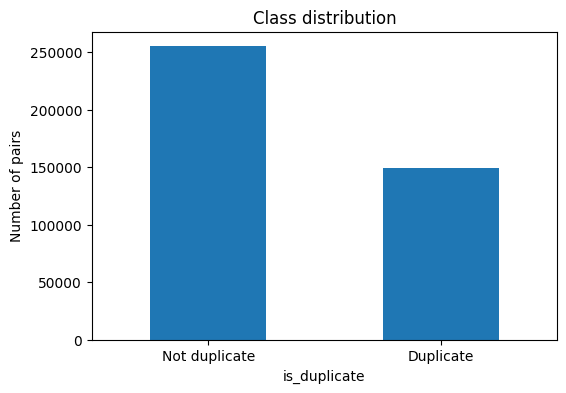

In [6]:
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

all_qids = pd.concat([df["qid1"], df["qid2"]], ignore_index=True)
print("\nUnique question IDs:", all_qids.nunique())
print("Total question occurrences:", len(all_qids))
print("Question IDs appearing more than once:", (all_qids.value_counts() > 1).sum())

plt.figure(figsize=(6, 4))
df["is_duplicate"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Not duplicate", "Duplicate"], rotation=0)
plt.ylabel("Number of pairs")
plt.title("Class distribution")
plt.show()

## 4. Modelling sample and train/test split

The old notebook later models the first 100K rows and uses a 70/30 split.  
Here we retain that setup but make it reproducible and stratified.

In [7]:
work = df.iloc[:N_ROWS].copy() if N_ROWS is not None else df.copy()

work["question1"] = work["question1"].fillna("")
work["question2"] = work["question2"].fillna("")

train_df, test_df = train_test_split(
    work,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=work["is_duplicate"],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("\nTrain distribution:")
print(train_df["is_duplicate"].value_counts(normalize=True).round(4))
print("\nTest distribution:")
print(test_df["is_duplicate"].value_counts(normalize=True).round(4))

Train: (70000, 6)
Test : (30000, 6)

Train distribution:
is_duplicate
0    0.6275
1    0.3725
Name: proportion, dtype: float64

Test distribution:
is_duplicate
0    0.6275
1    0.3725
Name: proportion, dtype: float64


## 5. Text preprocessing

Based on your original notebook:
- lowercase
- expand common contractions
- normalize numbers/currency
- remove HTML and punctuation
- optional stopword removal
- token-wise Porter stemming

In [8]:
CONTRACTIONS = {
    "won't": "will not",
    "cannot": "can not",
    "can't": "can not",
    "what's": "what is",
    "it's": "it is",
    "i'm": "i am",
    "he's": "he is",
    "she's": "she is",
}

def normalize_text(text, remove_stopwords=False, stem=False):
    text = str(text).lower()
    text = (
        text.replace(",000,000", "m")
            .replace(",000", "k")
            .replace("′", "'")
            .replace("’", "'")
    )

    for old, new in CONTRACTIONS.items():
        text = text.replace(old, new)

    text = (
        text.replace("n't", " not")
            .replace("'ve", " have")
            .replace("'re", " are")
            .replace("'ll", " will")
            .replace("%", " percent ")
            .replace("₹", " rupee ")
            .replace("$", " dollar ")
            .replace("€", " euro ")
    )

    text = re.sub(r"([0-9]+)000000", r"\\1m", text)
    text = re.sub(r"([0-9]+)000", r"\\1k", text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"[^a-z0-9]+", " ", text)

    tokens = text.split()

    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]

    if stem:
        tokens = [PORTER.stem(t) for t in tokens]

    return " ".join(tokens).strip()

## 6. Basic engineered features

Preserved feature ideas:
- question-ID frequency
- character length
- word count
- common unique words
- total unique words
- word share
- sum/difference of frequencies

Frequency statistics are learned from the training split only.

In [9]:
def qid_frequency_map(train):
    counts = pd.concat(
        [train["qid1"], train["qid2"]], ignore_index=True
    ).value_counts()
    return counts.to_dict()

QID_FREQ = qid_frequency_map(train_df)

def basic_features(frame):
    out = pd.DataFrame(index=frame.index)

    q1 = frame["question1"].astype(str)
    q2 = frame["question2"].astype(str)

    out["freq_qid1"] = frame["qid1"].map(QID_FREQ).fillna(0).astype("float32")
    out["freq_qid2"] = frame["qid2"].map(QID_FREQ).fillna(0).astype("float32")

    out["q1len"] = q1.str.len().astype("float32")
    out["q2len"] = q2.str.len().astype("float32")
    out["q1_n_words"] = q1.str.split().str.len().astype("float32")
    out["q2_n_words"] = q2.str.split().str.len().astype("float32")

    common, total, share = [], [], []

    for a, b in zip(q1, q2):
        w1 = set(x.lower().strip() for x in a.split())
        w2 = set(x.lower().strip() for x in b.split())

        c = len(w1 & w2)
        t = len(w1) + len(w2)

        common.append(c)
        total.append(t)
        share.append(c / (t + SAFE_DIV))

    out["word_Common"] = np.array(common, dtype=np.float32)
    out["word_Total"] = np.array(total, dtype=np.float32)
    out["word_share"] = np.array(share, dtype=np.float32)
    out["freq_q1+q2"] = out["freq_qid1"] + out["freq_qid2"]
    out["freq_q1-q2"] = (out["freq_qid1"] - out["freq_qid2"]).abs()

    return out

train_basic = basic_features(train_df)
test_basic = basic_features(test_df)

display(train_basic.head())

,freq_qid1,freq_qid2,q1len,q2len,q1_n_words,q2_n_words,word_Common,word_Total,word_share,freq_q1+q2,freq_q1-q2
0,1.0,1.0,31.0,49.0,3.0,3.0,0.0,6.0,0.000000,2.0,0.0
1,1.0,1.0,42.0,33.0,10.0,7.0,5.0,16.0,0.312498,2.0,0.0
2,1.0,1.0,119.0,212.0,22.0,40.0,9.0,51.0,0.176470,2.0,0.0
3,2.0,1.0,43.0,79.0,7.0,10.0,3.0,16.0,0.187499,3.0,1.0
4,1.0,1.0,33.0,38.0,6.0,6.0,1.0,12.0,0.083333,2.0,0.0


## 7. Advanced NLP and fuzzy features

The same feature family as the old case study:

- common non-stopword ratios: `cwc_min`, `cwc_max`
- common stopword ratios: `csc_min`, `csc_max`
- common-token ratios: `ctc_min`, `ctc_max`
- first/last-word equality
- absolute/mean token length
- fuzzy ratio, partial ratio, token-sort ratio, token-set ratio
- longest-common-substring ratio

In [10]:
def token_features(q1, q2):
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if not q1_tokens or not q2_tokens:
        return [0.0] * 10

    q1_words = set(w for w in q1_tokens if w not in STOP_WORDS)
    q2_words = set(w for w in q2_tokens if w not in STOP_WORDS)
    q1_stops = set(w for w in q1_tokens if w in STOP_WORDS)
    q2_stops = set(w for w in q2_tokens if w in STOP_WORDS)

    common_words = len(q1_words & q2_words)
    common_stops = len(q1_stops & q2_stops)
    common_tokens = len(set(q1_tokens) & set(q2_tokens))

    return [
        common_words / (min(len(q1_words), len(q2_words)) + SAFE_DIV),
        common_words / (max(len(q1_words), len(q2_words)) + SAFE_DIV),
        common_stops / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV),
        common_stops / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV),
        common_tokens / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV),
        common_tokens / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV),
        float(q1_tokens[-1] == q2_tokens[-1]),
        float(q1_tokens[0] == q2_tokens[0]),
        float(abs(len(q1_tokens) - len(q2_tokens))),
        float((len(q1_tokens) + len(q2_tokens)) / 2),
    ]

def longest_substr_ratio(a, b):
    if not a or not b:
        return 0.0
    match = SequenceMatcher(None, a, b).find_longest_match(
        0, len(a), 0, len(b)
    )
    return match.size / (min(len(a), len(b)) + 1.0)

ADV_COLS = [
    "cwc_min", "cwc_max", "csc_min", "csc_max",
    "ctc_min", "ctc_max", "last_word_eq", "first_word_eq",
    "abs_len_diff", "mean_len",
    "token_set_ratio", "token_sort_ratio",
    "fuzz_ratio", "fuzz_partial_ratio",
    "longest_substr_ratio",
]

def advanced_features(frame):
    rows = []

    iterator = zip(frame["question1"], frame["question2"])

    for q1_raw, q2_raw in tqdm(
        iterator, total=len(frame), desc="Advanced features"
    ):
        q1 = normalize_text(q1_raw)
        q2 = normalize_text(q2_raw)

        feats = token_features(q1, q2)
        feats += [
            float(fuzz.token_set_ratio(q1, q2)),
            float(fuzz.token_sort_ratio(q1, q2)),
            float(fuzz.ratio(q1, q2)),
            float(fuzz.partial_ratio(q1, q2)),
            float(longest_substr_ratio(q1, q2)),
        ]
        rows.append(feats)

    return pd.DataFrame(rows, columns=ADV_COLS).astype("float32")

train_adv = advanced_features(train_df)
test_adv = advanced_features(test_df)

display(train_adv.head())

Advanced features:   0%|          | 0/70000 [00:00<?, ?it/s]

Advanced features:   0%|          | 0/30000 [00:00<?, ?it/s]

,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,token_set_ratio,token_sort_ratio,fuzz_ratio,fuzz_partial_ratio,longest_substr_ratio
0,0.666644,0.666644,0.000000,0.000000,0.133332,0.111110,0.0,0.0,3.0,16.5,75.000000,75.675674,72.972977,93.103447,0.800000
1,0.666644,0.666644,0.999980,0.833319,0.874989,0.699993,1.0,1.0,2.0,9.0,91.803276,78.378380,81.081078,78.787880,0.352941
2,0.333331,0.307690,0.624992,0.333331,0.428569,0.224999,0.0,0.0,19.0,30.5,55.849056,48.447205,37.267082,47.777779,0.035088
3,0.749981,0.749981,0.000000,0.000000,0.428565,0.272725,1.0,0.0,4.0,9.0,78.260872,56.198349,57.851238,81.690140,0.651163
4,0.333322,0.333322,0.333322,0.333322,0.333328,0.333328,0.0,1.0,0.0,6.0,75.362320,72.463768,57.971016,60.377357,0.333333


## 8. Clean question text for vectorization

In [11]:
def make_clean_questions(frame):
    q1 = np.array([
        normalize_text(x, remove_stopwords=True, stem=True)
        for x in tqdm(frame["question1"], desc="Clean q1")
    ], dtype=object)

    q2 = np.array([
        normalize_text(x, remove_stopwords=True, stem=True)
        for x in tqdm(frame["question2"], desc="Clean q2")
    ], dtype=object)

    return q1, q2

train_q1_clean, train_q2_clean = make_clean_questions(train_df)
test_q1_clean, test_q2_clean = make_clean_questions(test_df)

Clean q1:   0%|          | 0/70000 [00:00<?, ?it/s]

Clean q2:   0%|          | 0/70000 [00:00<?, ?it/s]

Clean q1:   0%|          | 0/30000 [00:00<?, ?it/s]

Clean q2:   0%|          | 0/30000 [00:00<?, ?it/s]

## 9. Numeric engineered matrix

Raw `id`, `qid1`, `qid2` values are not used as numeric magnitudes.

In [12]:
X_train_num_df = pd.concat(
    [train_basic.reset_index(drop=True), train_adv.reset_index(drop=True)],
    axis=1,
)

X_test_num_df = pd.concat(
    [test_basic.reset_index(drop=True), test_adv.reset_index(drop=True)],
    axis=1,
)

X_train_num = csr_matrix(X_train_num_df.to_numpy(dtype=np.float32))
X_test_num = csr_matrix(X_test_num_df.to_numpy(dtype=np.float32))

y_train = train_df["is_duplicate"].to_numpy()
y_test = test_df["is_duplicate"].to_numpy()

print("Numeric features:", X_train_num_df.shape[1])
print("Train:", X_train_num.shape, y_train.shape)
print("Test :", X_test_num.shape, y_test.shape)

Numeric features: 26
Train: (70000, 26) (70000,)
Test : (30000, 26) (30000,)


## 10. TF-IDF unigram/bigram features

Separate TF-IDF spaces are created for Question 1 and Question 2, as in the source notebook.  
They are fit on training data only.

In [13]:
q1_vectorizer = TfidfVectorizer(
    min_df=10,
    ngram_range=(1, 2),
    max_features=TFIDF_MAX_FEATURES,
)

q2_vectorizer = TfidfVectorizer(
    min_df=10,
    ngram_range=(1, 2),
    max_features=TFIDF_MAX_FEATURES,
)

X_train_q1_tfidf = q1_vectorizer.fit_transform(train_q1_clean)
X_test_q1_tfidf = q1_vectorizer.transform(test_q1_clean)

X_train_q2_tfidf = q2_vectorizer.fit_transform(train_q2_clean)
X_test_q2_tfidf = q2_vectorizer.transform(test_q2_clean)

X_train_tfidf = hstack(
    [X_train_num, X_train_q1_tfidf, X_train_q2_tfidf]
).tocsr()

X_test_tfidf = hstack(
    [X_test_num, X_test_q1_tfidf, X_test_q2_tfidf]
).tocsr()

print("TF-IDF train:", X_train_tfidf.shape)
print("TF-IDF test :", X_test_tfidf.shape)

TF-IDF train: (70000, 10026)
TF-IDF test : (30000, 10026)


## 11. Random baseline

In [14]:
rng = np.random.default_rng(RANDOM_STATE)

random_pred = rng.random((len(y_test), 2))
random_pred /= random_pred.sum(axis=1, keepdims=True)

random_logloss = log_loss(y_test, random_pred)
print("Random baseline test log loss:", round(random_logloss, 4))

Random baseline test log loss: 0.8873


## 12. Logistic Regression-style model

The source notebook uses `SGDClassifier(loss="log")`.  
Modern sklearn uses `loss="log_loss"`.

Probability calibration is retained because the main metric is log loss.

In [15]:
alphas = [10 ** x for x in range(-5, 2)]
lr_scores = []

for alpha in alphas:
    estimator = SGDClassifier(
        alpha=alpha,
        penalty="l2",
        loss="log_loss",
        random_state=RANDOM_STATE,
        max_iter=2000,
        tol=1e-3,
        n_jobs=-1,
    )

    model = CalibratedClassifierCV(estimator, method="sigmoid", cv=3)
    model.fit(X_train_tfidf, y_train)

    pred = model.predict_proba(X_test_tfidf)
    score = log_loss(y_test, pred)

    lr_scores.append((alpha, score))
    print(f"alpha={alpha:<8g} log loss={score:.4f}")

best_lr_alpha, best_lr_logloss = min(lr_scores, key=lambda z: z[1])
print("\nBest Logistic alpha:", best_lr_alpha)
print("Best Logistic test log loss:", round(best_lr_logloss, 4))

alpha=1e-05    log loss=0.6369
alpha=0.0001   log loss=0.5492
alpha=0.001    log loss=0.6119
alpha=0.01     log loss=0.6060
alpha=0.1      log loss=0.5719
alpha=1        log loss=0.5481
alpha=10       log loss=0.5818

Best Logistic alpha: 1
Best Logistic test log loss: 0.5481


## 13. Linear SVM + calibration

In [16]:
svm_scores = []

for alpha in alphas:
    estimator = SGDClassifier(
        alpha=alpha,
        penalty="l1",
        loss="hinge",
        random_state=RANDOM_STATE,
        max_iter=2000,
        tol=1e-3,
    )

    model = CalibratedClassifierCV(estimator, method="sigmoid", cv=3)
    model.fit(X_train_tfidf, y_train)

    pred = model.predict_proba(X_test_tfidf)
    score = log_loss(y_test, pred)

    svm_scores.append((alpha, score))
    print(f"alpha={alpha:<8g} log loss={score:.4f}")

best_svm_alpha, best_svm_logloss = min(svm_scores, key=lambda z: z[1])
print("\nBest SVM alpha:", best_svm_alpha)
print("Best SVM test log loss:", round(best_svm_logloss, 4))

alpha=1e-05    log loss=0.5194
alpha=0.0001   log loss=0.6245
alpha=0.001    log loss=0.8827
alpha=0.01     log loss=0.9658
alpha=0.1      log loss=0.5755
alpha=1        log loss=0.6418
alpha=10       log loss=0.6200

Best SVM alpha: 1e-05
Best SVM test log loss: 0.5194


## 14. Load pretrained 300-D GloVe

This replaces the old external `glove_vectors` pickle file.

In [17]:
print("Loading", GLOVE_MODEL_NAME)
glove = api.load(GLOVE_MODEL_NAME)
print("Dimension:", glove.vector_size)
print("Vocabulary size:", len(glove.key_to_index))

Loading glove-wiki-gigaword-300
[==================================================] 100.0% 376.1/376.1MB downloaded
Dimension: 300
Vocabulary size: 400000


## 15. TF-IDF-weighted GloVe

For each question:

\[
v(q)=
\frac{\sum_w TFIDF(w)\cdot GloVe(w)}
{\sum_w TFIDF(w)}
\]

IDF is learned only from training questions.

In [18]:
combined_train_text = np.concatenate([train_q1_clean, train_q2_clean])

glove_tfidf = TfidfVectorizer()
glove_tfidf.fit(combined_train_text)

idf_map = dict(
    zip(
        glove_tfidf.get_feature_names_out(),
        glove_tfidf.idf_,
    )
)

default_idf = float(np.max(glove_tfidf.idf_))

def tfidf_weighted_glove(sentences):
    dim = glove.vector_size
    vectors = np.zeros((len(sentences), dim), dtype=np.float32)

    for i, sentence in enumerate(tqdm(sentences, desc="TFIDF-GloVe")):
        words = sentence.split()
        counts = Counter(words)
        n_words = max(len(words), 1)

        weighted = np.zeros(dim, dtype=np.float32)
        total_weight = 0.0

        for word, count in counts.items():
            if word in glove.key_to_index:
                tf = count / n_words
                weight = tf * idf_map.get(word, default_idf)
                weighted += glove[word] * weight
                total_weight += weight

        if total_weight > 0:
            vectors[i] = weighted / total_weight

    return vectors

X_train_q1_glove = tfidf_weighted_glove(train_q1_clean)
X_train_q2_glove = tfidf_weighted_glove(train_q2_clean)
X_test_q1_glove = tfidf_weighted_glove(test_q1_clean)
X_test_q2_glove = tfidf_weighted_glove(test_q2_clean)

TFIDF-GloVe:   0%|          | 0/70000 [00:00<?, ?it/s]

TFIDF-GloVe:   0%|          | 0/70000 [00:00<?, ?it/s]

TFIDF-GloVe:   0%|          | 0/30000 [00:00<?, ?it/s]

TFIDF-GloVe:   0%|          | 0/30000 [00:00<?, ?it/s]

## 16. Combine engineered + GloVe features

In [19]:
X_train_glove = np.hstack([
    X_train_num_df.to_numpy(dtype=np.float32),
    X_train_q1_glove,
    X_train_q2_glove,
])

X_test_glove = np.hstack([
    X_test_num_df.to_numpy(dtype=np.float32),
    X_test_q1_glove,
    X_test_q2_glove,
])

print("Train:", X_train_glove.shape)
print("Test :", X_test_glove.shape)

Train: (70000, 626)
Test : (30000, 626)


## 17. XGBoost

This uses a practical regularized setup so the full notebook is feasible in Colab.

In [20]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.10,
    reg_lambda=5.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

xgb_model.fit(
    X_train_glove,
    y_train,
    eval_set=[(X_test_glove, y_test)],
    verbose=False,
)

xgb_pred = xgb_model.predict_proba(X_test_glove)
xgb_logloss = log_loss(y_test, xgb_pred)

print("XGBoost test log loss:", round(xgb_logloss, 4))

XGBoost test log loss: 0.3775


## 18. Model comparison

In [21]:
results = pd.DataFrame({
    "Representation": [
        "Random",
        "TF-IDF + engineered",
        "TF-IDF + engineered",
        "TF-IDF-weighted GloVe + engineered",
    ],
    "Model": [
        "Random baseline",
        "Logistic Regression",
        "Linear SVM",
        "XGBoost",
    ],
    "Test Log Loss": [
        random_logloss,
        best_lr_logloss,
        best_svm_logloss,
        xgb_logloss,
    ],
}).sort_values("Test Log Loss")

display(results)

,Representation,Model,Test Log Loss
3,TF-IDF-weighted GloVe + engineered,XGBoost,0.377548
2,TF-IDF + engineered,Linear SVM,0.519419
1,TF-IDF + engineered,Logistic Regression,0.548120
0,Random,Random baseline,0.887253


## 19. XGBoost diagnostic classification results

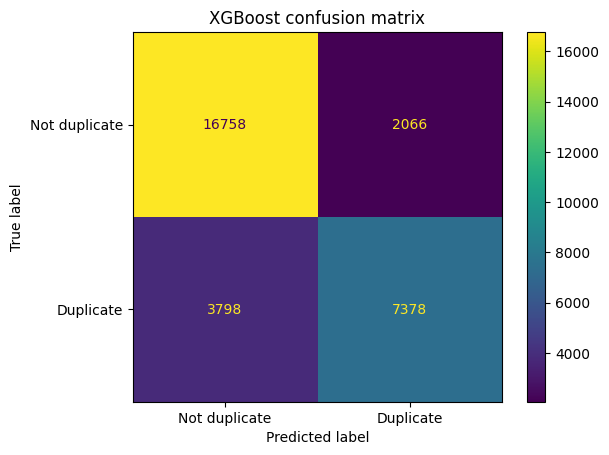

               precision    recall  f1-score   support

Not duplicate       0.82      0.89      0.85     18824
    Duplicate       0.78      0.66      0.72     11176

     accuracy                           0.80     30000
    macro avg       0.80      0.78      0.78     30000
 weighted avg       0.80      0.80      0.80     30000



In [22]:
xgb_class = (xgb_pred[:, 1] >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_class,
    display_labels=["Not duplicate", "Duplicate"],
)
plt.title("XGBoost confusion matrix")
plt.show()

print(classification_report(
    y_test,
    xgb_class,
    target_names=["Not duplicate", "Duplicate"],
))

# Interview-ready explanation

> I framed Quora duplicate-question detection as binary classification. After EDA and text normalization, I engineered question-frequency, length, word-overlap, token-overlap, fuzzy-matching and longest-common-substring features. I then compared unigram/bigram TF-IDF with TF-IDF-weighted pretrained GloVe representations. I benchmarked calibrated Logistic Regression and Linear SVM, and used XGBoost on the dense semantic plus engineered features. Because the required output is a probability rather than just a hard class, I used log loss as the main metric.

### You should be able to explain
- why exact word matching is insufficient
- why log loss is used
- `word_share`
- `cwc`, `csc`, `ctc`
- fuzzy ratios
- TF-IDF
- GloVe
- TF-IDF-weighted GloVe
- why SVM needs calibration
- why XGBoost can work well with engineered NLP features
- what leakage is and how this version reduces it

# Source-result note

Your original uploaded notebook reports:

| Representation | Model | Test log loss |
|---|---|---:|
| TF-IDF | Random model | 0.8908 |
| TF-IDF | Logistic Regression | 0.5728 |
| TF-IDF | Linear SVM | 0.5964 |
| TF-IDF-weighted W2V/GloVe | XGBoost | **0.3335** |

Do **not** assume this cleaned notebook will reproduce exactly 0.3335.  
After running it, save the actual metric you obtain and be prepared to explain that run.